In [1]:

# 📥 Instalación de librerías (ejecutar solo una vez)
!pip install ipywidgets librosa numpy matplotlib scipy
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import Audio, display
import ipywidgets as widgets
from ipywidgets import interact
# ⚙️ Configuración de gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Entorno listo. Puede continuar con la Parte 1.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.2 MB/s eta 0:00:00
✅ Entorno listo. Puede continuar con la Parte 1.


**Ejecute esta celda primero. Instala las librerías necesarias y configura el entorno de
visualización.**

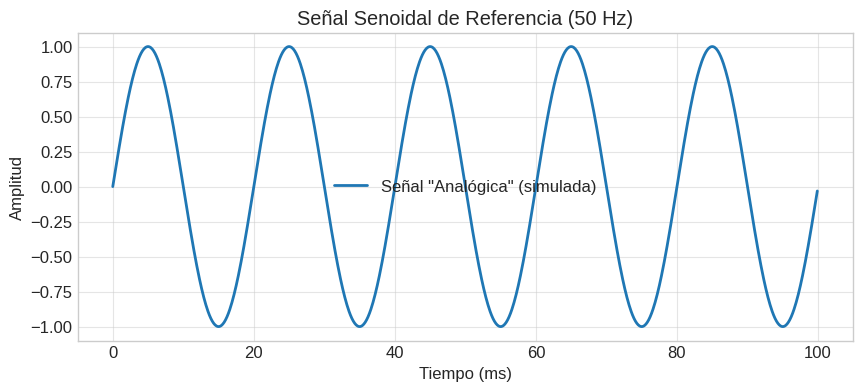

🔊 Reproduciendo señal de referencia...


In [2]:

# 📝 Parámetros de la señal
frecuencia_original = 50 # Hz (frecuencia de la onda)
duracion = 0.1 # segundos
fs_analogico = 10000 # Hz (muy alto para simular continuidad)
# 📐 Generar eje de tiempo
t = np.linspace(0, duracion, int(fs_analogico * duracion), endpoint=False)
# 🌊 Generar onda senoidal pura (señal analógica simulada)
senal_analogica = np.sin(2 * np.pi * frecuencia_original * t)
# 📊 Visualización
plt.figure(figsize=(10, 4))
plt.plot(t * 1000, senal_analogica, label='Señal "Analógica" (simulada)', linewidth=2)
plt.title('Señal Senoidal de Referencia (50 Hz)')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()
# 🔊 Escuchar (opcional, requiere audio habilitado en el navegador)
print("🔊 Reproduciendo señal de referencia...")
display(Audio(senal_analogica, rate=fs_analogico))



**Parte 1:La Señal "Analógica" (Referencia)
El mundo real es continuo. Para visualizarlo en la computadora, simularemos una señal "analógica" usando una frecuencia de muestreo muy alta (10,000 Hz), que servirá como nuestra referencia ideal.**
Concepto clave: En la naturaleza, la onda es una línea continua. La computadora aún no la ha "medido". Ahora daremos el primer paso: tomar muestras.

In [8]:
def visualizar_muestreo(fs_muestreo):
    """Función que muestrea la señal y compara con la referencia"""
    # Generar tiempos de muestreo
    t_muestreo = np.arange(0, duracion, 1/fs_muestreo)
    # Tomar muestras de la señal analógica
    muestras = np.sin(2 * np.pi * frecuencia_original * t_muestreo)
    # Gráfico comparativo
    plt.figure(figsize=(10, 4))
    plt.plot(t * 1000, senal_analogica, 'gray', alpha=0.5, label='Señal original')
    plt.stem(t_muestreo * 1000, muestras, linefmt='b-', markerfmt='bo', basefmt='k-',
             label='Muestras tomadas')
    plt.title(f'Muestreo a {fs_muestreo} Hz')
    plt.xlabel('Tiempo (ms)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    # Explicación pedagógica
    if fs_muestreo < 2 * frecuencia_original:
        print("⚠️ ATENCIÓN: fs < 2×f. Estás por debajo del límite de Nyquist. ¡Aparecerá aliasing!")
    else:
        print("✅ Buen muestreo. La frecuencia de muestreo cumple Nyquist (fs ≥ 2×f).")

# 🎛️ CONTROL INTERACTIVO
print("🎛️ Use el deslizador para cambiar la frecuencia de muestreo (50 Hz a 200 Hz)")
interact(visualizar_muestreo, fs_muestreo=widgets.IntSlider(min=50, max=200, step=10, value=100, description='fs (Hz):'));

🎛️ Use el deslizador para cambiar la frecuencia de muestreo (50 Hz a 200 Hz)


interactive(children=(IntSlider(value=100, description='fs (Hz):', max=200, min=50, step=10), Output()), _dom_…

**3. Parte 2: Muestreo Interactivo (Sampling)
El muestreo consiste en tomar "fotografías" de la señal a intervalos regulares. Usemos un
control deslizante para ver cómo cambia la representación al variar la frecuencia de
muestreo (fs).**

---

### 📝

#### 📌 Pregunta 1: Mueva el control a $fs = 100\text{ Hz}$. ¿Qué observa?
* **Respuesta:** Al configurar $fs = 100\text{ Hz}$, estamos exactamente en el **Límite de Nyquist**, ya que la frecuencia original de nuestra onda ($f$) es de $50\text{ Hz}$ y la fórmula nos indica que $fs = 2 \cdot f$ ($2 \cdot 50 = 100$).
* **Observación Visual:** En el gráfico se observa que se toman exactamente **dos muestras por cada ciclo completo** de la onda (un pico positivo y un valle negativo). Aunque visualmente la onda parezca un triángulo o una señal cuadrada al unir los puntos de forma directa, matemáticamente es el **mínimo absoluto necesario** para reconstruir la frecuencia original de $50\text{ Hz}$ sin perder su identidad.



#### 📌 Pregunta 2: Bájelo a $fs = 60\text{ Hz}$. ¿Sigue representándose bien la onda?
* **Respuesta:** No, la onda ya no se representa correctamente porque estamos violando el Teorema de Nyquist ($fs < 2 \cdot f$, dado que $60\text{ Hz} < 100\text{ Hz}$). Al estar por debajo de este umbral crítico, se produce el fenómeno de **Aliasing** (solapamiento).
* **Observación Visual:** Las muestras capturadas quedan tan distanciadas entre sí que, al intentar unirlas para reconstruir la señal, producen la ilusión geométrica de una onda con una frecuencia muchísimo más baja (más lenta) que la original de $50\text{ Hz}$. La información de la velocidad real de la onda se perdió por completo.



#### 📌 Pregunta 3: Suba a $fs = 200\text{ Hz}$. ¿Mejora o empeora la fidelidad?
* **Respuesta:** La fidelidad **mejora de forma drástica**. Al configurar un $fs = 200\text{ Hz}$, estamos realizando un sobre-muestreo de la señal a cuatro veces la frecuencia original ($fs = 4 \cdot f$).
* **Observación Visual:** El gráfico muestra ahora **cuatro puntos de medición por cada ciclo**. Al disponer de una mayor cantidad de muestras espaciadas a intervalos de tiempo más cortos, la forma digitalizada (los puntos azules) delinea con muchísima más fidelidad, precisión y suavidad la curva de la señal analógica de referencia.

In [13]:
def cuantizar_senal(bits):
    """Aplica cuantización de 'bits' a la señal muestreada y la visualiza"""
    # Muestreamos primero a una tasa segura
    fs_seguro = 1000
    t_seguro = np.arange(0, duracion, 1/fs_seguro)
    senal_muestreada = np.sin(2 * np.pi * frecuencia_original * t_seguro)
    # Fórmula de cuantización simétrica (normalizada entre -1 y 1)
    niveles = 2**bits
    señal_cuantizada = np.round(senal_muestreada * (niveles/2 - 1)) / (niveles/2 - 1)
    # Gráfico
    plt.figure(figsize=(10, 4))
    plt.plot(t_seguro * 1000, senal_muestreada, 'gray', alpha=0.6, label="""Señal muestreada
(continua)""")
    plt.plot(t_seguro * 1000, señal_cuantizada, 'r-', linewidth=2, label=f"""Cuantizada ({bits}
bits)""")
    plt.title(f'Cuantización: {bits} bits → {niveles} niveles posibles')
    plt.xlabel('Tiempo (ms)')
    plt.ylabel('Amplitud cuantizada')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    # Explicación
    print(f"📊 Con {bits} bits tenemos {niveles} niveles. "
          f"El 'escalado' visible es el ruido de cuantización.")
# 🎛️ Control interactivo
print("🎛️ Ajuste la profundidad de bits para ver el efecto en la precisión de amplitud")
interact(cuantizar_senal, bits=widgets.IntSlider(min=2, max=8, step=1, value=4,
description='Bits:'));

🎛️ Ajuste la profundidad de bits para ver el efecto en la precisión de amplitud


interactive(children=(IntSlider(value=4, description='Bits:', max=8, min=2), Output()), _dom_classes=('widget-…

**4. Parte 3: Cuantización Interactiva (Resolución en Bits)
Una vez muestreada, la amplitud debe convertirse a números enteros. Menos bits =
menos niveles posibles = más "escalones".**
Concepto clave:
* 8 bits = 256 niveles (suficiente para voz básica)
* 16 bits = 65,536 niveles (estándar CD)
* Menos bits → sonido "metálico" o "pixelado" (ruido de cuantización)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


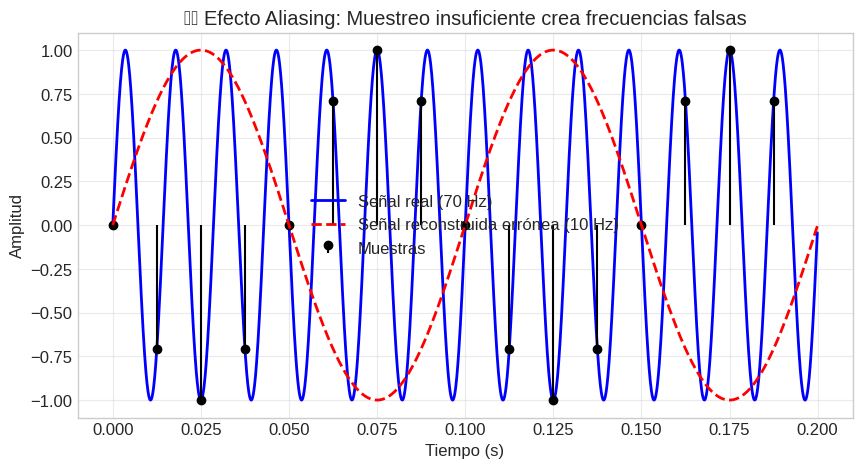

📌 Teorema de Nyquist: fs debe ser ≥ 140 Hz para 70 Hz.
📌 Usamos fs = 80 Hz → ¡INFERIOR AL LÍMITE!
📌 Resultado: El cerebro/computadora interpreta una onda de 10 Hz.


In [15]:
def demostrar_aliasing():
    """Compara señal original, muestreo insuficiente y reconstrucción errónea"""
    # Frecuencias
    f_alta = 70 # Hz (señal real)
    fs_baja = 80 # Hz (frecuencia de muestreo)
    # Tiempos
    t = np.linspace(0, 0.2, 2000, endpoint=False)
    t_muestreo = np.arange(0, 0.2, 1/fs_baja)
    # Señales
    senal_real = np.sin(2 * np.pi * f_alta * t)
    muestras = np.sin(2 * np.pi * f_alta * t_muestreo)
    # Frecuencia que "percibimos" al reconstruir mal (alias)
    f_alias = abs(f_alta - fs_baja) # 70 - 80 = 10 Hz (en valor absoluto)
    senal_alias = np.sin(2 * np.pi * f_alias * t)
    # Gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(t, senal_real, 'b', linewidth=2, label=f'Señal real ({f_alta} Hz)')
    plt.stem(t_muestreo, muestras, linefmt='k-', markerfmt='ko', basefmt=' ',
             label='Muestras')
    plt.plot(t, senal_alias, 'r--', linewidth=2, label=f'Señal reconstruida errónea ({f_alias} Hz)')
    plt.title('⚠️ Efecto Aliasing: Muestreo insuficiente crea frecuencias falsas')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()
    print(f"📌 Teorema de Nyquist: fs debe ser ≥ {2*f_alta} Hz para {f_alta} Hz.")
    print(f"📌 Usamos fs = {fs_baja} Hz → ¡INFERIOR AL LÍMITE!")
    print(f"📌 Resultado: El cerebro/computadora interpreta una onda de {f_alias} Hz.")
demostrar_aliasing()

**5. Parte 4: Aliasing (Solapamiento Frecuencial)
Demostración visual de qué ocurre cuando violamos el teorema de Nyquist. Una
frecuencia alta "se disfraza" como una baja.**
Analogía visual: Es el mismo efecto que las ruedas de un coche en video que parecen
girar al revés. La cámara (muestreo) no captura suficiente información para representar la
velocidad real.

/tmp/ipykernel_5416/1205801987.py:33: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_5416/1205801987.py:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


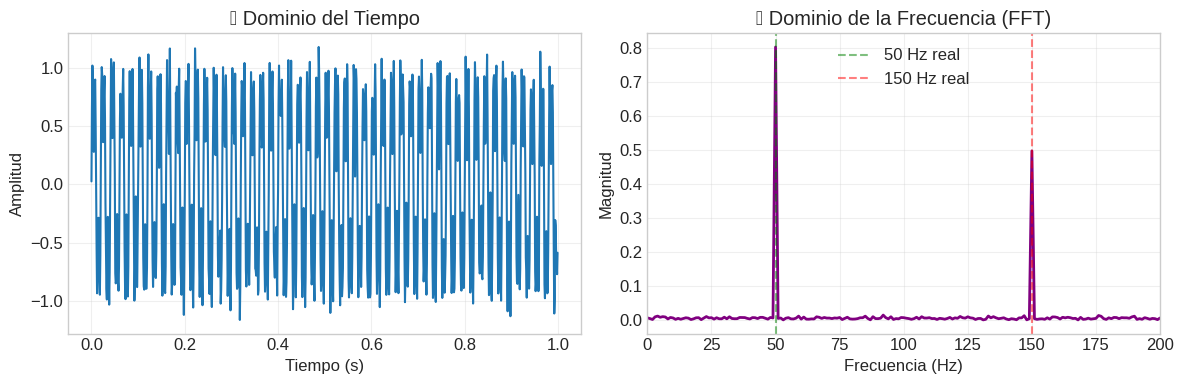

🔍 Observe los picos en 50 Hz y 150 Hz. La FFT descompone la señal en sus
'notas' individuales.


In [17]:
def analisis_fourier_simple():
    """Genera una señal compuesta y muestra su espectro de frecuencias"""
    fs = 1000
    t = np.linspace(0, 1, fs, endpoint=False)
    # Señal compuesta: 50 Hz + 150 Hz + ruido leve
    senal = 0.8 * np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 150 * t) + 0.1 * \
            np.random.randn(len(t))
    # 🔄 Transformada Rápida de Fourier (FFT)
    espectro = np.fft.fft(senal)
    frecuencias = np.fft.fftfreq(len(senal), d=1/fs)
    # Tomamos solo la mitad positiva (el espectro es simétrico)
    idx_pos = frecuencias >= 0
    f_pos = frecuencias[idx_pos]
    amp_pos = np.abs(espectro[idx_pos]) * 2 / len(senal) # Normalización
    # Gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    # Dominio del tiempo
    ax1.plot(t, senal, linewidth=1.5)
    ax1.set_title('📈 Dominio del Tiempo')
    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Amplitud')
    ax1.grid(True, alpha=0.3)
    # Dominio de la frecuencia
    ax2.plot(f_pos, amp_pos, color='purple', linewidth=2)
    ax2.set_title('📊 Dominio de la Frecuencia (FFT)')
    ax2.set_xlabel('Frecuencia (Hz)')
    ax2.set_ylabel('Magnitud')
    ax2.set_xlim(0, 200)
    ax2.grid(True, alpha=0.3)
    ax2.axvline(50, color='g', linestyle='--', alpha=0.5, label='50 Hz real')
    ax2.axvline(150, color='r', linestyle='--', alpha=0.5, label='150 Hz real')
    ax2.legend()
    plt.tight_layout()

    # ISPC / Tecnicatura Superior en Ciencia de Datos e Inteligencia Artificial

    plt.show()
    print("""🔍 Observe los picos en 50 Hz y 150 Hz. La FFT descompone la señal en sus
'notas' individuales.""")
analisis_fourier_simple()

**6. Parte 5: Dominio del Tiempo vs. Dominio de la Frecuencia
La Transformada de Fourier nos permite ver "qué ingredientes (frecuencias)" tiene un sonido.**
Concepto clave: El dominio del tiempo responde "¿cuándo suena?". El dominio de la frecuencia responde "¿qué tonos hay?". Ambos son la misma señal, vista desde ángulos distintos.

---

# 📝 Resolución de Actividades: Laboratorio N°1

## 📌 1. Muestreo (Sampling)
**Pregunta:** Si graba un tono puro de $300\text{ Hz}$, ¿cuál es la frecuencia de muestreo mínima teórica para evitar aliasing? ¿Por qué en la práctica se usa un valor mayor?

<div style="text-align: justify;">

* **Frecuencia Mínima Teórica:** Según el **Teorema de Muestreo de Nyquist-Shannon**, la frecuencia de muestreo ($f_s$) debe ser estrictamente mayor al doble de la frecuencia máxima de la señal ($f_{max}$).
    $$f_s > 2 \cdot f_{max} \implies f_s > 2 \cdot 300\text{ Hz} = 600\text{ Hz}$$
    La tasa mínima teórica es de **$600\text{ Hz}$**.
* **Razón de uso de valores mayores en la práctica:** En el mundo físico, los filtros analógicos (pasabajos) no son perfectos, es decir, no cortan la señal de manera vertical y abrupta justo en los $300\text{ Hz}$. Requieren una "zona de transición" suave para operar sin introducir distorsiones de fase. Un margen mayor mediante sobre-muestreo otorga el espacio necesario para que estos componentes actúen eficientemente. Además, muestrear a una tasa más alta distribuye el ruido de cuantización a lo largo de un espectro de frecuencias más amplio, facilitando su posterior filtrado y mejorando significativamente la fidelidad general de la señal digitalizada.

</div>

---

## 📌 2. Cuantización (Resolución en Bits)
**Pregunta:** Un audio de estudio se graba a $24\text{ bits}$ y $48\text{ kHz}$. Otro archivo comprimido para web usa $8\text{ bits}$ y $22\text{ kHz}$. Describa dos diferencias auditivas y visuales que esperaría encontrar entre ambos.

<div style="text-align: justify;">

### 📊 Diferencias Visuales (En los Gráficos de Colab)
* **En el dominio del tiempo:** El archivo optimizado para web ($8\text{ bits}$) exhibirá una onda notablemente escalonada debido a su baja resolución vertical, contando con apenas $2^8 = 256$ niveles posibles de amplitud. En contraste, el archivo de estudio ($24\text{ bits}$) presentará una curva completamente suave y continua, sustentada en sus más de 16 millones de niveles dinámicos ($2^{24}$). Asimismo, la tasa de $22\text{ kHz}$ mostrará una menor densidad horizontal de puntos de control por segundo en comparación con los $48\text{ kHz}$ del máster de estudio.
* **En el dominio de la frecuencia (FFT):** El archivo de $8\text{ bits}$ mostrará una línea de "piso de ruido" base significativamente más alta y desorganizada debido al error matemático intrínseco de la cuantización. Por otra parte, el espectro de la versión web se interrumpirá abruptamente al alcanzar los $11\text{ kHz}$ (su límite estricto de Nyquist), mientras que el archivo de estudio registrará componentes limpias y detalladas hasta los $24\text{ kHz}$.

### 🔊 Diferencias Auditivas (Percepción Sonora)
* **Rango Dinámico y Distorsión (Bits):** El audio comprimido para web manifestará un soplido o siseo constante de fondo (ruido de cuantización) bastante perceptible, y los pasajes con sonidos tenues o susurros se percibirán con una textura "metálica" o distorsionada. El máster de estudio ofrecerá un silencio absoluto de fondo, preservando una fidelidad milimétrica tanto en los umbrales más sutiles como en los picos de mayor sonoridad.
* **Brillo y Claridad (Frecuencia):** El audio codificado a $22\text{ kHz}$ se percibirá opaco, apagado o "encajonado" (de forma similar a una comunicación telefónica convencional) debido a su incapacidad para reproducir frecuencias superiores a los $11\text{ kHz}$, cancelando los armónicos agudos esenciales. El registro de $48\text{ kHz}$ cubrirá con holgura todo el espectro audible por el ser humano ($20\text{ Hz}$ a $20\text{ kHz}$), logrando una reproducción acústica brillante, espaciosa y cristalina.

</div>

---

## 📌 3. Aliasing (Solapamiento Frecuencial)
**Pregunta:** En el código de la Parte 4, cambie $f\_alta = 90$ y $fs\_baja = 80$. Ejecute mentalmente o en código: ¿qué frecuencia "falsa" aparecerá? Explique el cálculo.

<div style="text-align: justify;">

* **Frecuencia Falsa Detectada (Alias):** En pantalla se registrará una frecuencia falsa o alias de **$10\text{ Hz}$**.
* **Explicación del Cálculo:** Al quebrantar activamente el teorema de Nyquist (debido a que la tasa de muestreo $fs = 80\text{ Hz}$ resulta inferior al doble de la señal real requerida, que sería $2 \cdot 90 = 180\text{ Hz}$), la frecuencia real experimenta un fenómeno de pliegue matemático y se proyecta dentro de la zona permitida por la tasa de muestreo. Esto se calcula formalmente aplicando el valor absoluto de la diferencia:
    $$f_{alias} = |f_{real} - f_s| = |90\text{ Hz} - 80\text{ Hz}| = 10\text{ Hz}$$
    Dado que los intervalos de captura de muestras coinciden en puntos donde la onda original de $90\text{ Hz}$ ya ha completado un ciclo entero más una fracción, el sistema de cómputo es incapaz de procesar las oscilaciones internas perdidas. Por consiguiente, el algoritmo reconstruye de manera errónea una señal sinusoidal ralentizada de apenas $10\text{ Hz}$.

</div>

---

## 📌 4. Dominios (Tiempo vs. Frecuencia)
**Pregunta:** Si aplica la FFT a un archivo `.wav` de voz humana y observa un pico dominante en $220\text{ Hz}$, ¿qué información le da esto sobre la señal original? ¿Podría distinguirse de un silbido de $220\text{ Hz}$ solo con este pico?

<div style="text-align: justify;">

* **Información aportada por el pico:** Ese componente espectral específico nos revela la **Frecuencia Fundamental ($F_0$)** de la voz en esa ventana temporal analizada. En el ámbito de la acústica del habla humana, un valor fundamental de $220\text{ Hz}$ se vincula de manera directa con el tono característico de una voz femenina o con el rango agudo de una locución estándar, indicando con precisión la velocidad física de vibración de las cuerdas vocales del locutor.
* **¿Se puede distinguir de un silbido solo con este pico?** **No**, resulta técnicamente imposible diferenciarlos analizando de forma aislada ese único pico fundamental. Un silbido se aproxima notablemente al comportamiento de una onda senoidal pura; en una representación de FFT se manifestaría casi de manera exclusiva esa línea filosa en los $220\text{ Hz}$ con un entorno limpio de energía. En contraste, la voz humana cuenta con un timbre denso y complejo. Aunque localice su mayor energía en los $220\text{ Hz}$, la transformada de Fourier de la voz desglosará una arquitectura de componentes secundarios perfectamente ordenados (múltiplos enteros denominados armónicos: $440\text{ Hz}$, $660\text{ Hz}$, $880\text{ Hz}$, etc.) junto con sobreelevaciones provocadas por las cavidades de resonancia del tracto vocal. Para discriminarlos con rigor científico, los algoritmos de clasificación analizan la estructura espectral global o implementan la extracción de coeficientes avanzados como los **MFCC**.

</div>